In [24]:
import utility_functions as utils
import GLM
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
import numpy.matlib
sns.set_theme()

# Estimating coupling filter from neuron 1 to neuron 2

It's a simple scenario where external stimulus (e.g. visual stimulus) affects both neuron 1 and neuron 2, and there is also a one-way coupling effect from neuron 1 to neuron 2 ($\gamma_{2,1,:}$). We don't consider self effects (i.e. $\gamma_{1,1,:}$ and $\gamma_{2,2,:}$ are all zeros) or the effect from neuron 2 to neuron 1 (i.e. $\gamma_{1,2,:}$ are all zeros).

## Creating ground truth

In [230]:
nt = 1000 # Say there are 1000 time bins each trial. Each time bin = 1ms. So each trial lasts for 1000ms
ntrial = 2000 # 5000 trials in total
time_line = np.arange(nt)
log_lambda_baseline = np.log(0.05) # the baseline firing rate is 0.05 spikes/ms or 50 spikes/s
log_lambda_stimulus = 0.1* np.exp(-((time_line-300)/100)**2) # stimulus drives the firing rate higher around t=200ms. 
# We assume stimulus is the same for every trial. 

log_lambda_neuron1 = log_lambda_baseline + log_lambda_stimulus
lambda_neuron1 = np.exp(log_lambda_neuron1)
spike_neuron1 = np.random.poisson(lam=np.matlib.repmat(lambda_neuron1[:,np.newaxis],1,ntrial), size=None)


Text(0.5, 1.0, 'ground truth stimulus effect')

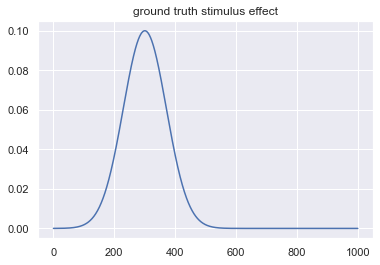

In [231]:
plt.plot(time_line, log_lambda_stimulus)
plt.title('ground truth stimulus effect')

In [232]:
spike_neuron1.shape

(1000, 2000)

Let's assume the synapses from neuron 1 to neuron 2 is excitatory. Spikes of neuron 1 have positive effect on neuron 2 firing rate. Note that we have 30 previous histories in the ground truth model. 

Text(0.5, 1.0, 'ground truth $\\gamma_{2,1,:}$')

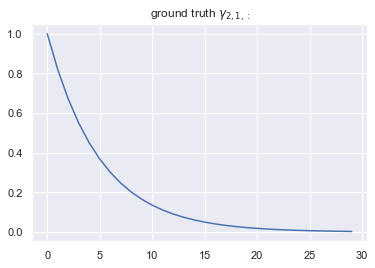

In [233]:
coupling_length = 30
time_line_coupling = np.arange(coupling_length)
ground_truth_coupling_filter = np.exp(-time_line_coupling/5)
plt.plot(ground_truth_coupling_filter)
plt.title('ground truth $\gamma_{2,1,:}$')

In [234]:
log_lambda_coupling = GLM.conv(spike_neuron1, ground_truth_coupling_filter[:, np.newaxis])
log_lambda_coupling = log_lambda_coupling.reshape((nt, ntrial), order='F')
log_lambda_neuron2 = log_lambda_baseline + 0.5*log_lambda_stimulus[:,np.newaxis] + log_lambda_coupling
lambda_neuron2 = np.exp(log_lambda_neuron2)

In [235]:
lambda_neuron2.shape

(1000, 2000)

In [236]:
spike_neuron2 = np.random.poisson(lam=lambda_neuron2)

In [237]:
spike_neuron2.shape

(1000, 2000)

If we look at the log lambda of a given trial, we can see the firing rate of neuron 2 suddenly jump up when neuron 1 spikes. 

Text(0.5, 1.0, 'log firing rate of an example trial')

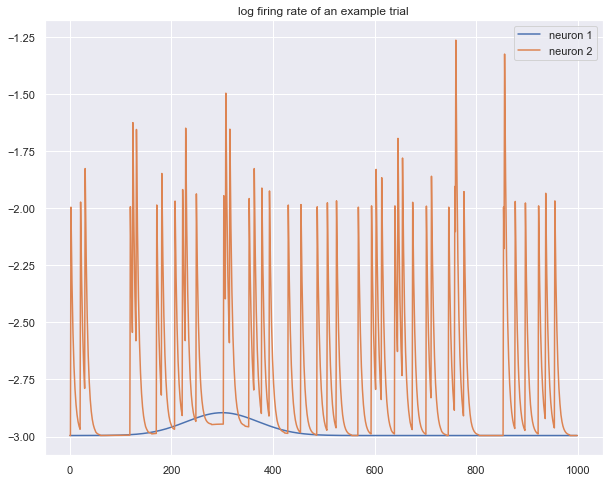

In [238]:
plt.subplots(figsize=(10,8))
plt.plot(log_lambda_neuron1, label='neuron 1')
plt.plot(log_lambda_neuron2[:,0], label='neuron 2')
plt.legend()
plt.title('log firing rate of an example trial')

# Fit GLM

Let fit a GLM where the input are inhomogeneous baseline (representing stimulus effect, denoted by $\alpha_{i, c_i(t)}$ in Emery Brown's 2021 paper) and coupling effect (denoted by $\gamma_{2, 1, :}$ in Emery Brown's 2021 paper). In theory we have 30 previous histories from $\gamma_{2, 1, 1}$ all the way to $\gamma_{2, 1, 30}$, but we can assume $\gamma_{2, 1, :}$ as a vector or a function is continuous and smooth. So we can assume $\gamma_{2, 1, :}$ is a linear combination of say five smooth basis functions (figure below). In this way, we reduce 30 parameters to 5 parameters. 

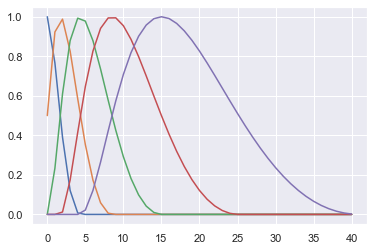

In [239]:
_ = GLM.make_pillow_basis(num=5, peaks_max=15, nonlinear=0.2, verbose=True)

We also use linear combination of basis functions to estimate inhomogeneous baseline ( $\alpha_{i, c_i(t)}$ ). Even we assume inhomogeneous baseline is the same for each trial, there are still 1000 time bins so 1000 parameters to estimate if we don't use basis functions. The basis functions are shown below. 

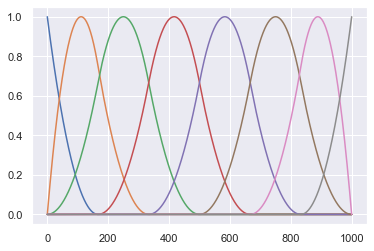

In [240]:
_ = GLM.inhomo_baseline(num=8, start=0, end=1e3, verbose=True)

The function I wrote should be easy to use. First we just initial the PP_GLM object, then we add all the effects that we want to included in the model as predictor. Finally, we fit the model where the target/outcome variable is neuron 2's spike trains. 

In [265]:
model = GLM.PP_GLM(ntrial=ntrial, nt=nt)
model.add_effect("inhomogeneous_baseline", num=10)
model.add_effect("coupling", raw_input=spike_neuron1, num=5, peaks_max=15, nonlinear=0.2)
model.fit(target=spike_neuron2, verbose=True)

Negative log likelihood is: 513202.19
aic/2 is: 513217.19


Let's compare the fitted results versus the ground truth. 

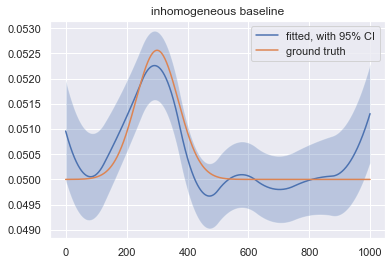

In [279]:
GLM.plot_GLM_one_effect(model, effect_id=0, label='fitted, with 95% CI', 
                       title='inhomogeneous baseline')
plt.plot(np.exp(0.5*log_lambda_stimulus+log_lambda_baseline), label="ground truth")
plt.legend()

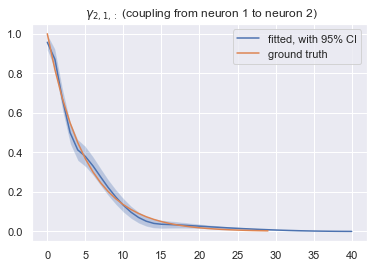

In [282]:
GLM.plot_GLM_one_effect(model, effect_id=1, label='fitted, with 95% CI', 
                        title=' $\gamma_{2, 1, :}$ (coupling from neuron 1 to neuron 2)')
plt.plot(ground_truth_coupling_filter, label="ground truth")
plt.legend()


Our estimated $\gamma_{2, 1, :}$ is pretty much the same as ground truth. Even we only used five basis functions and five parameters. 

# Conditioning on confounding variable

Here is anther interesting example showing how we can get rid of confounding effect by conditioning on the confounding variable. Say our confounding variable is just the common stimulus to the two neurons. We explicitly include stimulus' effect by adding inhomogeneous baseline, since the animal watch exactly the same picture each trial and visual stimulus should be more or less identical. 

## Not considering stimulus
Here is a simple case where I didn't add inhomogeneous baseline in the model, but just add a constant baseline ($\gamma_{i, 0}$ in Emery Brown 2011 Granger causality paper). 

Negative log likelihood is: 789316.00
aic/2 is: 789327.00
Negative log likelihood is: 619146.51
aic/2 is: 619157.51


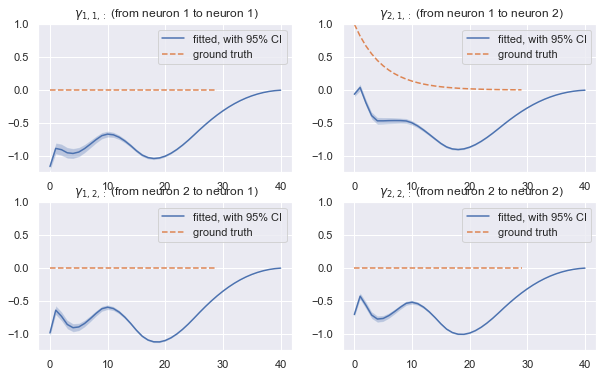

In [304]:
coupling_filter_params = {'peaks_max':15, 'num':5, 'nonlinear':0.2}
all_zero_coupling_filter = np.zeros(30)

plt.subplots(figsize=(10,6))
model = GLM.PP_GLM(ntrial=ntrial, nt=nt)
model.add_effect("homogeneous_baseline")
model.add_effect("coupling", raw_input=spike_neuron1, **coupling_filter_params)
model.add_effect("coupling", raw_input=spike_neuron2, **coupling_filter_params)
model.fit(target=spike_neuron2, verbose=True)
plt.subplot(2,2,2)
GLM.plot_GLM_one_effect(model, effect_id=1, label='fitted, with 95% CI', 
                        title=' $\gamma_{2, 1, :}$ (from neuron 1 to neuron 2)')
plt.plot(ground_truth_coupling_filter, '--', label="ground truth")
plt.ylim(-1.25,1)
plt.legend()
plt.subplot(2,2,4)
GLM.plot_GLM_one_effect(model, effect_id=2, label='fitted, with 95% CI', 
                        title=' $\gamma_{2, 2, :}$ (from neuron 2 to neuron 2)')
plt.plot(all_zero_coupling_filter, '--', label="ground truth")
plt.ylim(-1.25,1)
plt.legend()


model = GLM.PP_GLM(ntrial=ntrial, nt=nt)
model.add_effect("homogeneous_baseline")
model.add_effect("coupling", raw_input=spike_neuron1, **coupling_filter_params)
model.add_effect("coupling", raw_input=spike_neuron2, **coupling_filter_params)
model.fit(target=spike_neuron1, verbose=True)
plt.subplot(2,2,1)
GLM.plot_GLM_one_effect(model, effect_id=1, label='fitted, with 95% CI', 
                        title=' $\gamma_{1, 1, :}$ (from neuron 1 to neuron 1)')
plt.plot(all_zero_coupling_filter, '--', label="ground truth")
plt.ylim(-1.25,1)
plt.legend()
plt.subplot(2,2,3)
GLM.plot_GLM_one_effect(model, effect_id=2, label='fitted, with 95% CI', 
                        title=' $\gamma_{1, 2, :}$ (from neuron 2 to neuron 1)')
plt.plot(all_zero_coupling_filter, '--', label="ground truth")
plt.ylim(-1.25,1)
plt.legend()

We can see that none of the four coupling effects are correct. Their confidence intervals are signiﬁcantly different from zero, which are false positives. 

##  conditioning on stimulus

Negative log likelihood is: 513199.64
aic/2 is: 513219.64
Negative log likelihood is: 404471.63
aic/2 is: 404491.63


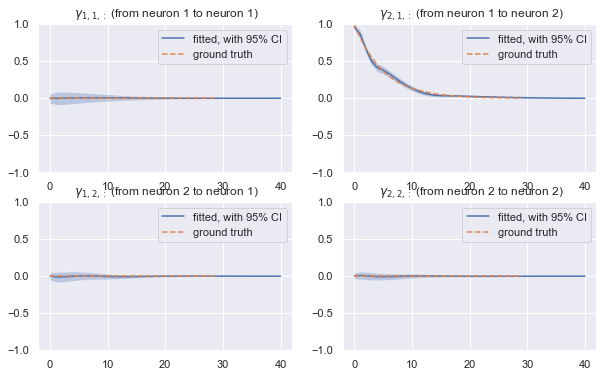

In [305]:
coupling_filter_params = {'peaks_max':15, 'num':5, 'nonlinear':0.2}
num_inhomo = 10

plt.subplots(figsize=(10,6))
model = GLM.PP_GLM(ntrial=ntrial, nt=nt)
model.add_effect("inhomogeneous_baseline", num=num_inhomo)
model.add_effect("coupling", raw_input=spike_neuron1, **coupling_filter_params)
model.add_effect("coupling", raw_input=spike_neuron2, **coupling_filter_params)
model.fit(target=spike_neuron2, verbose=True)
plt.subplot(2,2,2)
GLM.plot_GLM_one_effect(model, effect_id=1, label='fitted, with 95% CI', 
                        title=' $\gamma_{2, 1, :}$ (from neuron 1 to neuron 2)')
plt.plot(ground_truth_coupling_filter, '--', label="ground truth")
plt.ylim(-1,1)
plt.legend()
plt.subplot(2,2,4)
GLM.plot_GLM_one_effect(model, effect_id=2, label='fitted, with 95% CI', 
                        title=' $\gamma_{2, 2, :}$ (from neuron 2 to neuron 2)')
plt.plot(all_zero_coupling_filter, '--', label="ground truth")
plt.ylim(-1,1)
plt.legend()

model = GLM.PP_GLM(ntrial=ntrial, nt=nt)
model.add_effect("inhomogeneous_baseline", num=num_inhomo)
model.add_effect("coupling", raw_input=spike_neuron1, **coupling_filter_params)
model.add_effect("coupling", raw_input=spike_neuron2, **coupling_filter_params)
model.fit(target=spike_neuron1, verbose=True)
plt.subplot(2,2,1)
GLM.plot_GLM_one_effect(model, effect_id=1, label='fitted, with 95% CI', 
                        title=' $\gamma_{1, 1, :}$ (from neuron 1 to neuron 1)')
plt.plot(all_zero_coupling_filter, '--', label="ground truth")
plt.ylim(-1,1)
plt.legend()
plt.subplot(2,2,3)
GLM.plot_GLM_one_effect(model, effect_id=2, label='fitted, with 95% CI', 
                        title=' $\gamma_{1, 2, :}$ (from neuron 2 to neuron 1)')
plt.plot(all_zero_coupling_filter, '--', label="ground truth")
plt.ylim(-1,1)
plt.legend()

Just by changing constant baseline to a inhomogeneous baseline (a function of time from the start of each trial to the end), we rule out the effect from stimulus and keep the estimated coupling filter uncontaminated. The three non-existing history effects are not siginificantly different from zeros, and the existing history effect is correctly estimated. 